# Color Image Preprocessing

## RGB-HSV,Y'UV,CMYK
### HSV- Hue, Saturation, Value

Hue represents the dominant color in the image.Purity of color measured between degrees 0 to 360.
Red at 0,yellow at 60, green at 120,cyan at 150 and 240 blue.

Saturation represents the purity of the dominant color in the image

Value gives the brightness of the image clarity

### Y'UV-luma

Luma represents pixel brightness and darkness

U represnts amount of blue in a pixel (Y'-B)

V represents amout of red in a pixel Y'-R

### CMYK- Cyan Magenta Yellow Black
mainly used in printing as ink color

CMYK- 255 white and 0 black

RGB: 0-white and 255 black

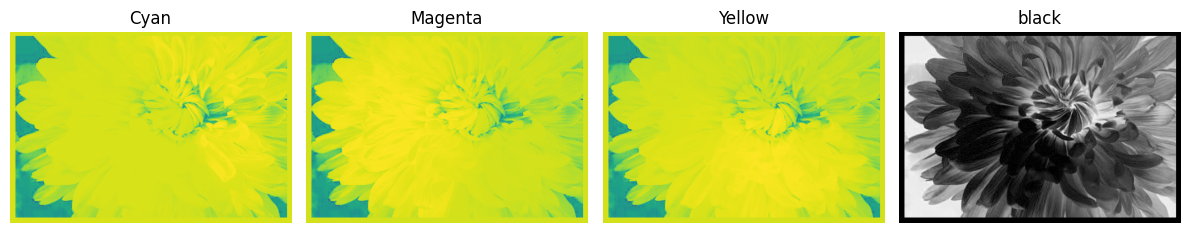

In [2]:
#CMYK
import matplotlib.pyplot as plt
import numpy as np
import cv2

#Read image in grayscale
image=cv2.imread(r'download 1.png')
rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
hsv=cv2.cvtColor(image,cv2.COLOR_BGR2HSV)

def rgb_cmyk(rgb):
    rgb=rgb.astype(float)/255
    R=rgb[:,:,0]
    G=rgb[:,:,1]
    B=rgb[:,:,2]

    K=1-np.maximum.reduce([R,G,B])

    C=np.zeros_like(K)
    M=np.zeros_like(K)
    Y=np.zeros_like(K)
    mask=K<1
    C[mask]=(1-R[mask]-K[mask]/(1-K[mask]))
    M[mask]=(1-G[mask]-K[mask]/(1-K[mask]))
    Y[mask]=(1-B[mask]-K[mask]/(1-K[mask]))
    return C,M,Y,K
C,M,Y,K=rgb_cmyk(rgb)
plt.figure(figsize=(12,5))
plt.subplot(1,4,1)
plt.imshow(C)
plt.title("Cyan")
plt.axis("off")

plt.subplot(1,4,2)

plt.imshow(M)
plt.title("Magenta")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(Y)
plt.title("Yellow")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(K,cmap="gray")
plt.title("black")
plt.axis("off")

plt.tight_layout()
plt.show()

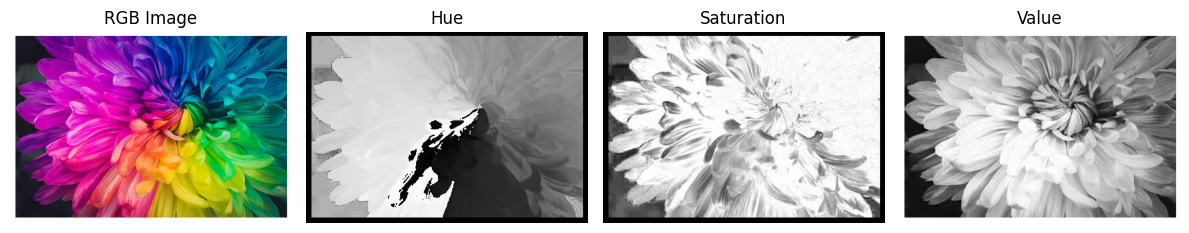

In [3]:
#HSV
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
image = cv2.imread(r"download 1.png")

# Convert BGR to RGB
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert RGB to HSV
hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)

# Extract H, S and V channels
h = hsv[:, :, 0]
s = hsv[:, :, 1]
v = hsv[:, :, 2]

# Display images
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(h, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(s, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(v, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

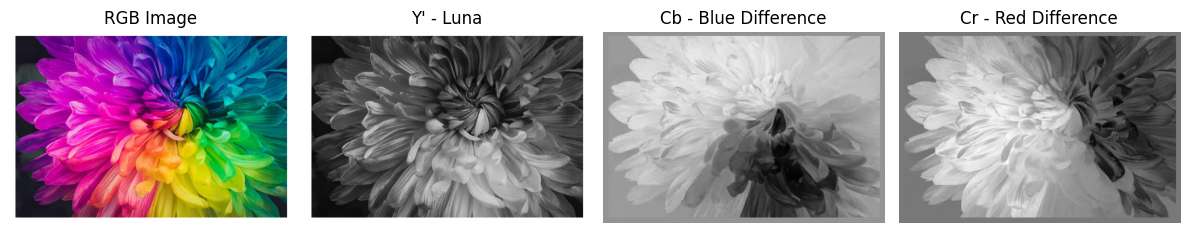

In [4]:
ycbr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
Y = ycbr[:, :, 0]
Cr = ycbr[:, :, 1]
Cb = ycbr[:, :, 2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Y, cmap='gray')
plt.title("Y' - Luna")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(Cb, cmap='gray')
plt.title("Cb - Blue Difference")
plt.axis('off')

plt.subplot(1, 4,4)
plt.imshow(Cr, cmap='gray')
plt.title("Cr - Red Difference")
plt.axis('off')

plt.tight_layout()
plt.show()

# Filter
## 1.Spatial Filtering(domain) - spatial resolution, digital in nature
## 2.Frequency filter(domain) - frequency resolution, analog in nature, forier transformation, when data is blurred

## 1. Spatial filtering:

   ### A. Smoothing-remove noise - mean, median, min and max
   
   ### B. Sharpening-extract edges

### 1. Smoothing
Remove noise:-

    mean- all cells in mask should be 1

    median-
    
    min
    
    max

# TRY
3X3 mean smoothing on gray image for blurring
sum and multiply pixels

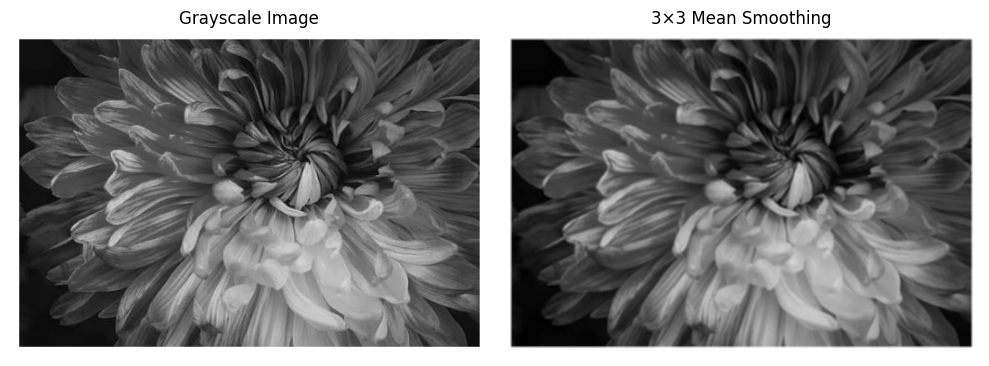

In [5]:
# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3x3 mean filter: sum neighboring pixels and multiply by 1/9
kernel = np.ones((3, 3), dtype=np.float32) / 9

blurred = cv2.filter2D(gray, -1, kernel)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap="gray")
plt.title("3×3 Mean Smoothing")
plt.axis("off")

plt.tight_layout()
plt.show()